# Sound & Audio Modeling

This notebook covers the fundamentals of audio signal processing and deep learning for audio, including:
1. Foundations of Audio & Signal Processing
2. Time-Frequency Representations
3. Classical Audio & Speech Modeling
4. Deep Learning for Audio
5. Practical Applications

## Setup and Imports

In [1]:
# Install required packages if needed
# !pip install torch torchaudio librosa soundfile matplotlib numpy scipy

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import librosa
import librosa.display
from scipy import signal
from scipy.fft import fft, ifft
from IPython.display import Audio, display

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

---
# 1. Foundations of Audio & Signal Processing

## 1.1 Sound as a Signal

Sound is a mechanical wave - a pressure disturbance propagating through a medium. When digitized, it becomes a discrete-time signal.

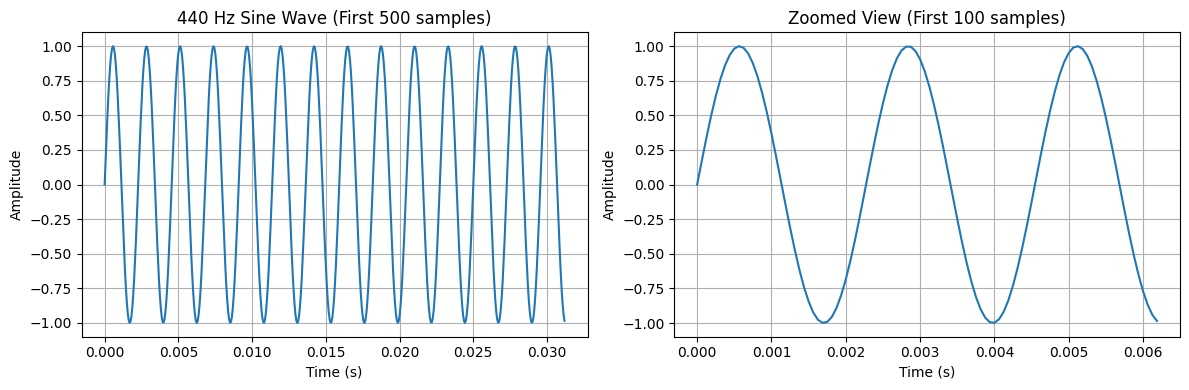

Playing 440 Hz sine wave:


In [7]:
# Generate a simple sine wave (pure tone)
sample_rate = 16000  # 16 kHz - common for speech
duration = 1.0  # 1 second
frequency = 440  # A4 note (440 Hz)

# Time axis
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Generate sine wave
sine_wave = np.sin(2 * np.pi * frequency * t)

# Plot the waveform
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t[:500], sine_wave[:500])  # Show first 500 samples
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'440 Hz Sine Wave (First 500 samples)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t[:100], sine_wave[:100])  # Show first 100 samples
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Zoomed View (First 100 samples)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Play the audio
print("Playing 440 Hz sine wave:")
display(Audio(sine_wave, rate=sample_rate))

## 1.2 Sampling Rate and Nyquist Theorem

**Nyquist-Shannon Theorem**: A signal can be perfectly reconstructed if sampled at least twice the highest frequency.

$$f_s \geq 2 f_{max}$$

Common sampling rates:
- 8,000 Hz: Telephone speech
- 16,000 Hz: Wideband speech (voice assistants)
- 44,100 Hz: CD quality audio
- 48,000 Hz: Professional video/broadcast

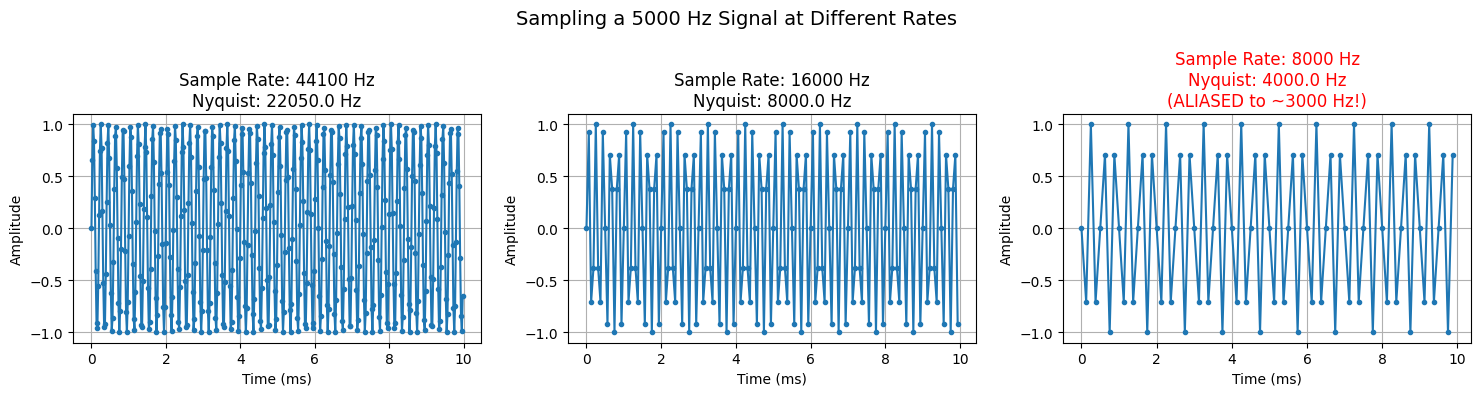

5000 Hz signal sampled at 8000 Hz aliases to: 3000 Hz


In [8]:
# Demonstrate aliasing - what happens when we undersample
original_sr = 44100  # Original high sample rate
target_freq = 5000  # 5 kHz tone

# Generate original high-quality signal
t_original = np.linspace(0, 0.01, int(original_sr * 0.01), endpoint=False)
original_signal = np.sin(2 * np.pi * target_freq * t_original)

# Undersample to different rates
undersample_rates = [44100, 16000, 8000]  # The 8kHz will alias!

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, sr in enumerate(undersample_rates):
    # Create time vector for undersampled signal
    t_under = np.linspace(0, 0.01, int(sr * 0.01), endpoint=False)
    signal_under = np.sin(2 * np.pi * target_freq * t_under)
    
    nyquist = sr / 2
    aliased = target_freq > nyquist
    
    axes[i].plot(t_under * 1000, signal_under, 'o-', markersize=3)
    axes[i].set_xlabel('Time (ms)')
    axes[i].set_ylabel('Amplitude')
    title = f'Sample Rate: {sr} Hz\nNyquist: {nyquist} Hz'
    if aliased:
        aliased_freq = abs(target_freq - sr)
        title += f'\n(ALIASED to ~{aliased_freq} Hz!)'
    axes[i].set_title(title, color='red' if aliased else 'black')
    axes[i].grid(True)

plt.suptitle(f'Sampling a {target_freq} Hz Signal at Different Rates', fontsize=14)
plt.tight_layout()
plt.show()

print(f"5000 Hz signal sampled at 8000 Hz aliases to: {abs(5000 - 8000)} Hz")

## 1.3 Digital Audio Representation

Once digitized, audio becomes a 1D tensor of shape `(T,)` where T is the number of samples.

Waveform shape: torch.Size([1, 32000])
Duration: 2.00 seconds
Sample rate: 16000 Hz
Number of samples: 32000


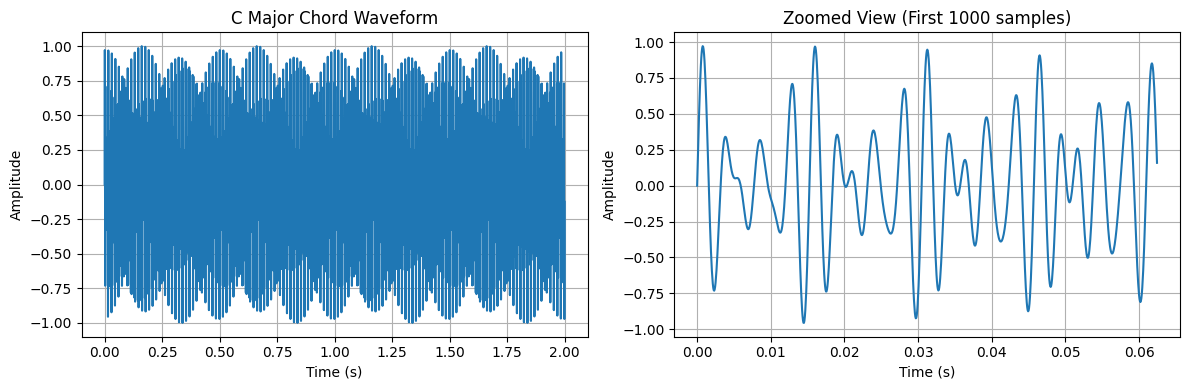

Playing C Major chord:


In [10]:
# Create a more complex audio signal - combining multiple frequencies
sample_rate = 16000
duration = 2.0
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Create a chord (C major: C4=262, E4=330, G4=392)
chord = (
    0.5 * np.sin(2 * np.pi * 262 * t) +  # C4
    0.4 * np.sin(2 * np.pi * 330 * t) +  # E4
    0.3 * np.sin(2 * np.pi * 392 * t)    # G4
)

# Normalize to [-1, 1]
chord = chord / np.max(np.abs(chord))

# Convert to PyTorch tensor
waveform = torch.tensor(chord, dtype=torch.float32).unsqueeze(0)  # Shape: (1, T)

print(f"Waveform shape: {waveform.shape}")
print(f"Duration: {waveform.shape[1] / sample_rate:.2f} seconds")
print(f"Sample rate: {sample_rate} Hz")
print(f"Number of samples: {waveform.shape[1]}")

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t, chord)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('C Major Chord Waveform')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t[:1000], chord[:1000])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Zoomed View (First 1000 samples)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Play the chord
print("Playing C Major chord:")
display(Audio(chord, rate=sample_rate))

---
# 2. The Fourier Transform

The Fourier Transform decomposes a signal into its constituent frequencies.

**DFT Formula**:
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi k n}{N}}$$

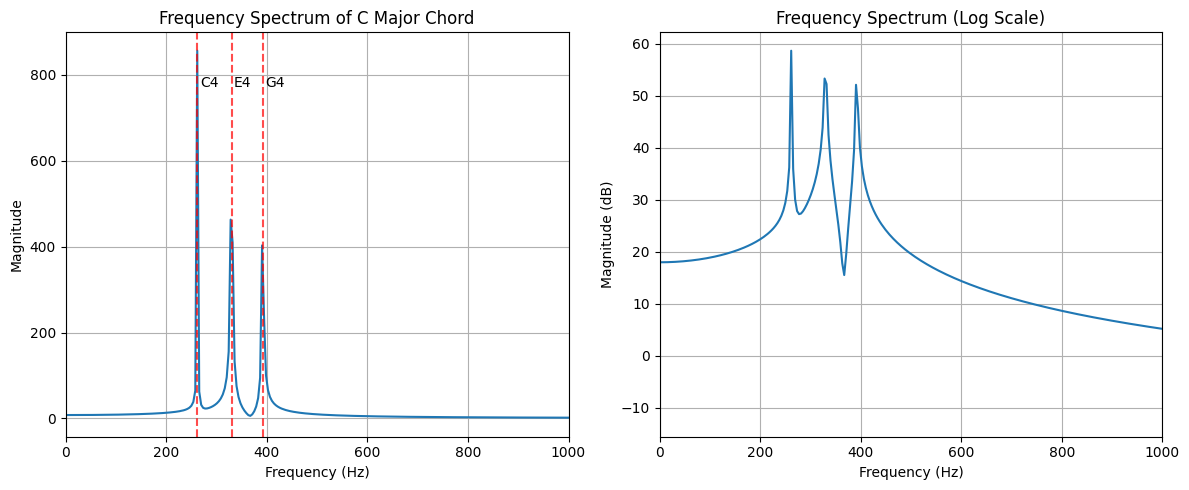

Peak frequencies detected:
  261.7 Hz (magnitude: 856.12)
  328.1 Hz (magnitude: 462.94)
  332.0 Hz (magnitude: 409.41)
  390.6 Hz (magnitude: 402.85)
  394.5 Hz (magnitude: 237.99)


In [11]:
# Compute the FFT of our chord signal
from scipy.fft import fft, fftfreq

# Take a segment of the signal
segment = chord[:4096]  # Power of 2 for efficient FFT
N = len(segment)

# Compute FFT
spectrum = fft(segment)
frequencies = fftfreq(N, 1/sample_rate)

# Get magnitude (only positive frequencies)
magnitude = np.abs(spectrum[:N//2])
positive_freqs = frequencies[:N//2]

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(positive_freqs, magnitude)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of C Major Chord')
plt.xlim(0, 1000)
plt.grid(True)

# Mark the expected frequencies
for freq, note in [(262, 'C4'), (330, 'E4'), (392, 'G4')]:
    plt.axvline(x=freq, color='r', linestyle='--', alpha=0.7)
    plt.text(freq+5, max(magnitude)*0.9, note, fontsize=10)

plt.subplot(1, 2, 2)
# Log scale magnitude (decibels)
magnitude_db = 20 * np.log10(magnitude + 1e-10)
plt.plot(positive_freqs, magnitude_db)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Frequency Spectrum (Log Scale)')
plt.xlim(0, 1000)
plt.grid(True)

plt.tight_layout()
plt.show()

print("Peak frequencies detected:")
peak_indices = np.argsort(magnitude)[-10:][::-1]
for idx in peak_indices[:5]:
    print(f"  {positive_freqs[idx]:.1f} Hz (magnitude: {magnitude[idx]:.2f})")

## 2.1 8-Point DFT Example

Let's compute a simple DFT by hand to understand the math.

Input signal x: [ 1  0 -1  0  1  0 -1  0]

DFT computed manually:
  X[0] = 0.00+0.00j
  X[1] = 0.00-0.00j
  X[2] = 4.00+0.00j
  X[3] = -0.00-0.00j
  X[4] = 0.00-0.00j
  X[5] = 0.00-0.00j
  X[6] = 4.00+0.00j
  X[7] = 0.00-0.00j

DFT using numpy.fft:
  X[0] = 0.00+0.00j
  X[1] = 0.00+0.00j
  X[2] = 4.00+0.00j
  X[3] = 0.00+0.00j
  X[4] = 0.00+0.00j
  X[5] = 0.00+0.00j
  X[6] = 4.00+0.00j
  X[7] = 0.00+0.00j


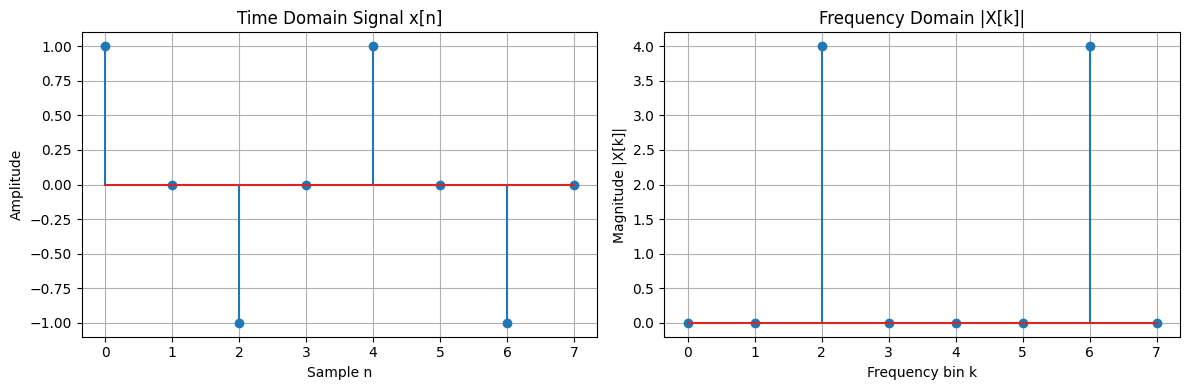


Interpretation: Energy at k=2 and k=6 (mirror due to real signal symmetry)
If sample rate = 8000 Hz, frequency at k=2 = 2000.0 Hz


In [12]:
# 8-Point DFT example from the lecture notes
x = np.array([1, 0, -1, 0, 1, 0, -1, 0])  # Simple alternating pattern
N = len(x)

# Compute DFT manually
X_manual = np.zeros(N, dtype=complex)
for k in range(N):
    for n in range(N):
        X_manual[k] += x[n] * np.exp(-2j * np.pi * k * n / N)

# Compute using numpy FFT
X_fft = np.fft.fft(x)

print("Input signal x:", x)
print("\nDFT computed manually:")
for k in range(N):
    print(f"  X[{k}] = {X_manual[k]:.2f}")

print("\nDFT using numpy.fft:")
for k in range(N):
    print(f"  X[{k}] = {X_fft[k]:.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(range(N), x)
axes[0].set_xlabel('Sample n')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Time Domain Signal x[n]')
axes[0].grid(True)

axes[1].stem(range(N), np.abs(X_fft))
axes[1].set_xlabel('Frequency bin k')
axes[1].set_ylabel('Magnitude |X[k]|')
axes[1].set_title('Frequency Domain |X[k]|')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nInterpretation: Energy at k=2 and k=6 (mirror due to real signal symmetry)")
print(f"If sample rate = 8000 Hz, frequency at k=2 = {2 * 8000 / 8} Hz")

---
# 3. Time-Frequency Representations

## 3.1 Windowing and Framing

Real audio is non-stationary. We divide it into short frames and analyze each frame separately.

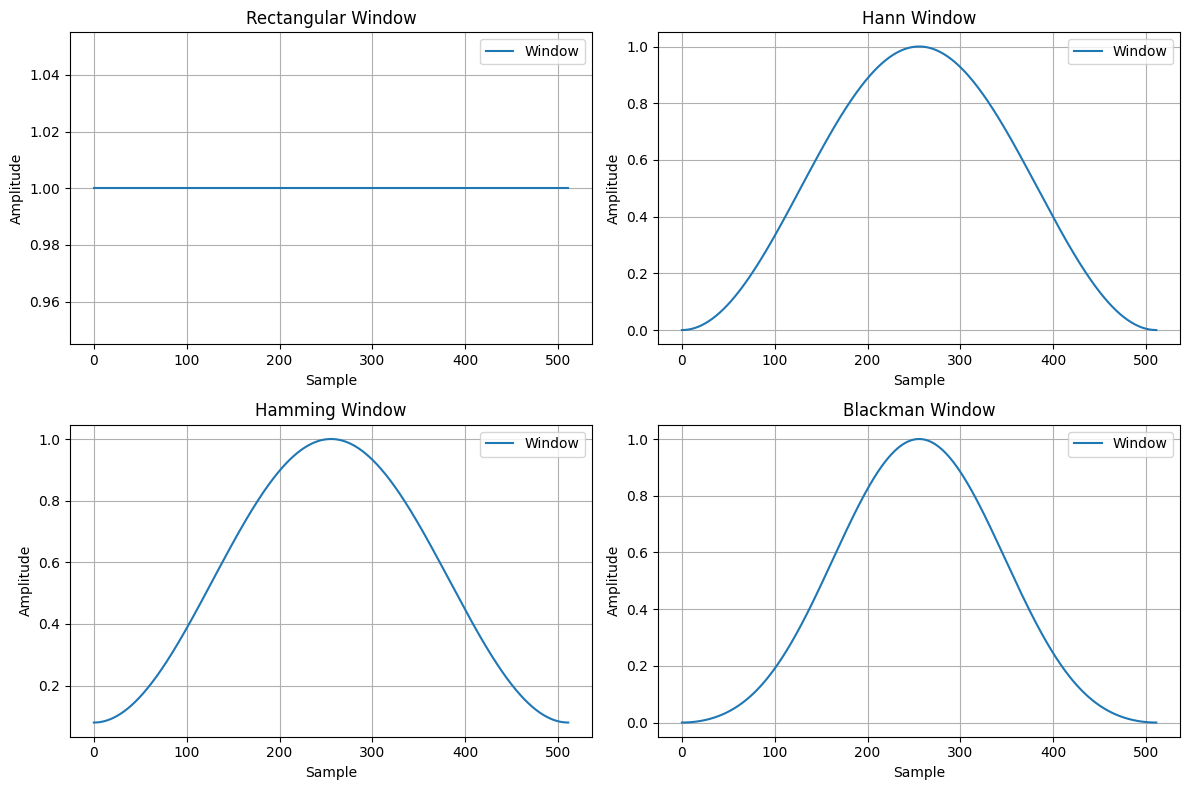

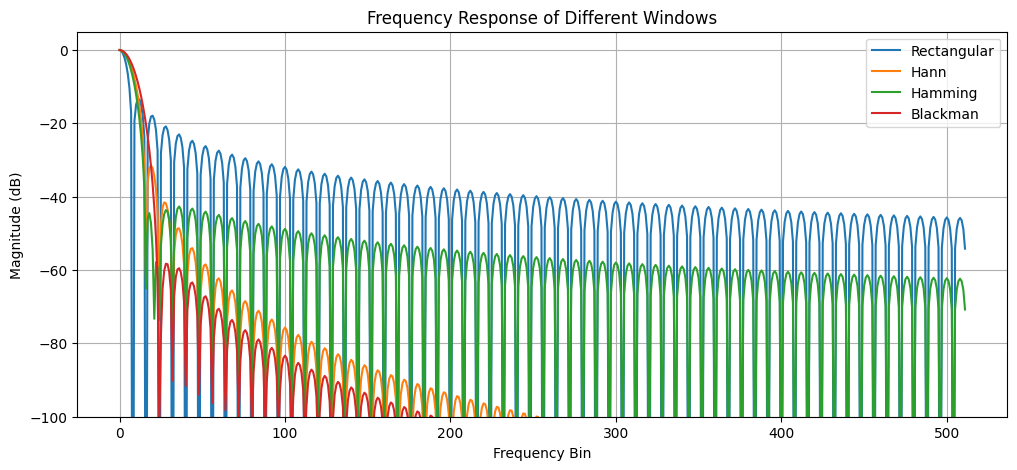

Notice: Smoother windows (Blackman) have better sidelobe suppression
but wider main lobe (worse frequency resolution).


In [13]:
# Demonstrate different window functions
window_size = 512

# Generate different windows
rectangular = np.ones(window_size)
hann = np.hanning(window_size)
hamming = np.hamming(window_size)
blackman = np.blackman(window_size)

# Plot windows
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

windows = [('Rectangular', rectangular), ('Hann', hann), 
           ('Hamming', hamming), ('Blackman', blackman)]

for ax, (name, window) in zip(axes.flat, windows):
    # Plot window in time domain
    ax.plot(window, label='Window')
    ax.set_title(f'{name} Window')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Show frequency response of windows
fig, ax = plt.subplots(figsize=(12, 5))

for name, window in windows:
    # Zero-pad for better frequency resolution
    padded = np.zeros(4096)
    padded[:window_size] = window
    
    # Compute frequency response
    freq_response = np.abs(fft(padded))
    freq_response_db = 20 * np.log10(freq_response / freq_response.max() + 1e-10)
    
    # Plot only first half (positive frequencies)
    ax.plot(freq_response_db[:512], label=name)

ax.set_xlabel('Frequency Bin')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('Frequency Response of Different Windows')
ax.set_ylim(-100, 5)
ax.legend()
ax.grid(True)
plt.show()

print("Notice: Smoother windows (Blackman) have better sidelobe suppression")
print("but wider main lobe (worse frequency resolution).")

## 3.2 Short-Time Fourier Transform (STFT)

The STFT applies the DFT to each windowed frame, giving us frequency content as a function of time.

$$X[m, k] = \sum_{n=0}^{N-1} x[n + mH] \cdot w[n] \cdot e^{-j\frac{2\pi kn}{N}}$$

Input shape: torch.Size([1, 32000])
STFT shape: torch.Size([1, 257, 251])
Number of frequency bins: 257
Number of time frames: 251


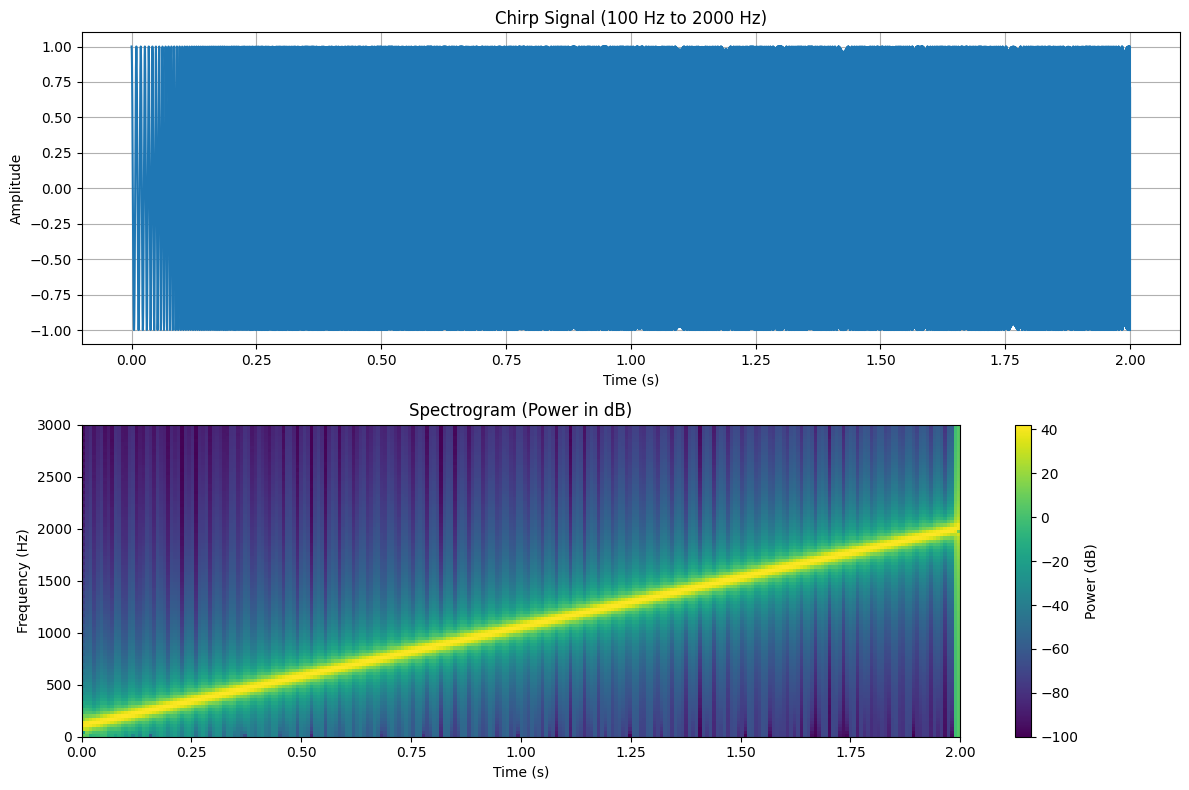

Playing chirp signal:


In [14]:
# Create a chirp signal (frequency sweep) to demonstrate STFT
sample_rate = 16000
duration = 2.0
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Generate chirp: frequency increases from 100 Hz to 2000 Hz
chirp = signal.chirp(t, f0=100, f1=2000, t1=duration, method='linear')

# STFT parameters
n_fft = 512
hop_length = 128
win_length = 512

# Compute STFT using torchaudio
chirp_tensor = torch.tensor(chirp, dtype=torch.float32).unsqueeze(0)
stft_transform = T.Spectrogram(
    n_fft=n_fft,
    win_length=win_length,
    hop_length=hop_length,
    power=2  # Power spectrogram
)
spectrogram = stft_transform(chirp_tensor)

# Convert to dB
spectrogram_db = 10 * torch.log10(spectrogram + 1e-10)

print(f"Input shape: {chirp_tensor.shape}")
print(f"STFT shape: {spectrogram.shape}")
print(f"Number of frequency bins: {spectrogram.shape[1]}")
print(f"Number of time frames: {spectrogram.shape[2]}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Waveform
axes[0].plot(t, chirp)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Chirp Signal (100 Hz to 2000 Hz)')
axes[0].grid(True)

# Spectrogram
img = axes[1].imshow(
    spectrogram_db.squeeze().numpy(),
    aspect='auto',
    origin='lower',
    extent=[0, duration, 0, sample_rate/2],
    cmap='viridis'
)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('Spectrogram (Power in dB)')
axes[1].set_ylim(0, 3000)
plt.colorbar(img, ax=axes[1], label='Power (dB)')

plt.tight_layout()
plt.show()

# Play the chirp
print("Playing chirp signal:")
display(Audio(chirp, rate=sample_rate))

## 3.3 Time-Frequency Trade-off

There's a fundamental trade-off: you cannot have precise resolution in both time and frequency simultaneously.

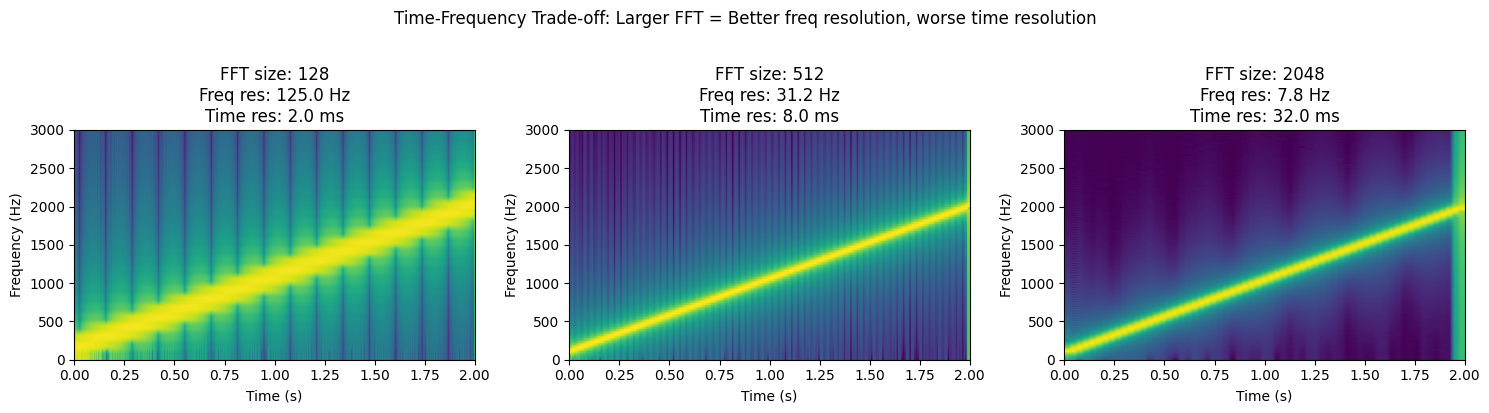

In [15]:
# Demonstrate time-frequency trade-off with different FFT sizes
fft_sizes = [128, 512, 2048]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n_fft in zip(axes, fft_sizes):
    hop_length = n_fft // 4
    
    # Compute spectrogram
    spec_transform = T.Spectrogram(
        n_fft=n_fft,
        hop_length=hop_length,
        power=2
    )
    spec = spec_transform(chirp_tensor)
    spec_db = 10 * torch.log10(spec + 1e-10)
    
    # Calculate resolutions
    freq_res = sample_rate / n_fft
    time_res = hop_length / sample_rate * 1000  # in ms
    
    img = ax.imshow(
        spec_db.squeeze().numpy(),
        aspect='auto',
        origin='lower',
        extent=[0, duration, 0, sample_rate/2],
        cmap='viridis'
    )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'FFT size: {n_fft}\n'
                 f'Freq res: {freq_res:.1f} Hz\n'
                 f'Time res: {time_res:.1f} ms')
    ax.set_ylim(0, 3000)

plt.suptitle('Time-Frequency Trade-off: Larger FFT = Better freq resolution, worse time resolution',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3.4 The Mel Scale

Human frequency perception is nonlinear. The Mel scale models this:

$$m = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

Hz to Mel conversion:
    100 Hz ->   150.5 Mel
    500 Hz ->   607.4 Mel
   1000 Hz ->  1000.0 Mel
   2000 Hz ->  1521.4 Mel
   4000 Hz ->  2146.1 Mel
   8000 Hz ->  2840.0 Mel


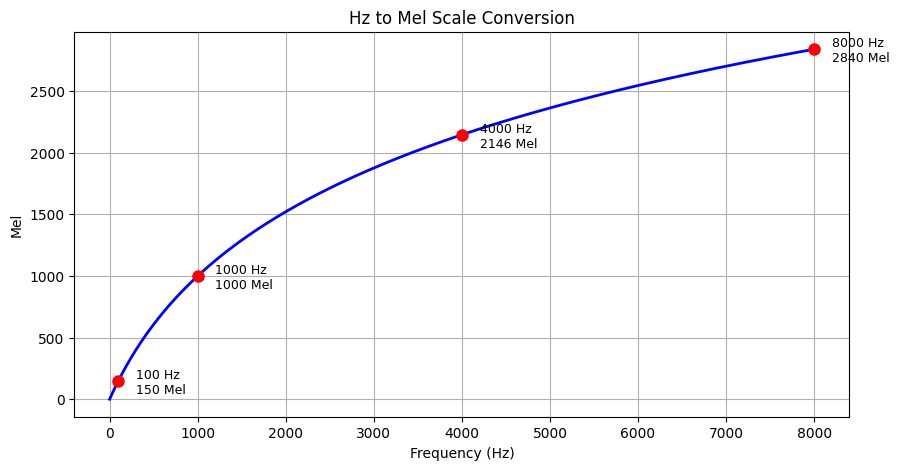


Notice: Equal intervals on the Mel scale correspond to
perceptually equal frequency differences.

The difference from 100-1000 Hz: 849 Mel
The difference from 4000-8000 Hz: 694 Mel


In [16]:
# Mel scale conversion functions
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)

# Demonstrate the conversion
frequencies_hz = np.array([100, 500, 1000, 2000, 4000, 8000])
frequencies_mel = hz_to_mel(frequencies_hz)

print("Hz to Mel conversion:")
for hz, mel in zip(frequencies_hz, frequencies_mel):
    print(f"  {hz:5d} Hz -> {mel:7.1f} Mel")

# Plot Hz vs Mel scale
hz_range = np.linspace(0, 8000, 1000)
mel_range = hz_to_mel(hz_range)

plt.figure(figsize=(10, 5))
plt.plot(hz_range, mel_range, 'b-', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mel')
plt.title('Hz to Mel Scale Conversion')
plt.grid(True)

# Mark some reference points
for hz in [100, 1000, 4000, 8000]:
    mel = hz_to_mel(hz)
    plt.plot(hz, mel, 'ro', markersize=8)
    plt.annotate(f'{hz} Hz\n{mel:.0f} Mel', 
                 xy=(hz, mel), xytext=(hz+200, mel-100),
                 fontsize=9)

plt.show()

print("\nNotice: Equal intervals on the Mel scale correspond to")
print("perceptually equal frequency differences.")
print(f"\nThe difference from 100-1000 Hz: {hz_to_mel(1000) - hz_to_mel(100):.0f} Mel")
print(f"The difference from 4000-8000 Hz: {hz_to_mel(8000) - hz_to_mel(4000):.0f} Mel")

## 3.5 Mel Spectrogram

A Mel spectrogram applies triangular filterbanks spaced according to the Mel scale.

Mel spectrogram shape: torch.Size([1, 80, 126])
  - Batch size: 1
  - Mel bins: 80
  - Time frames: 126


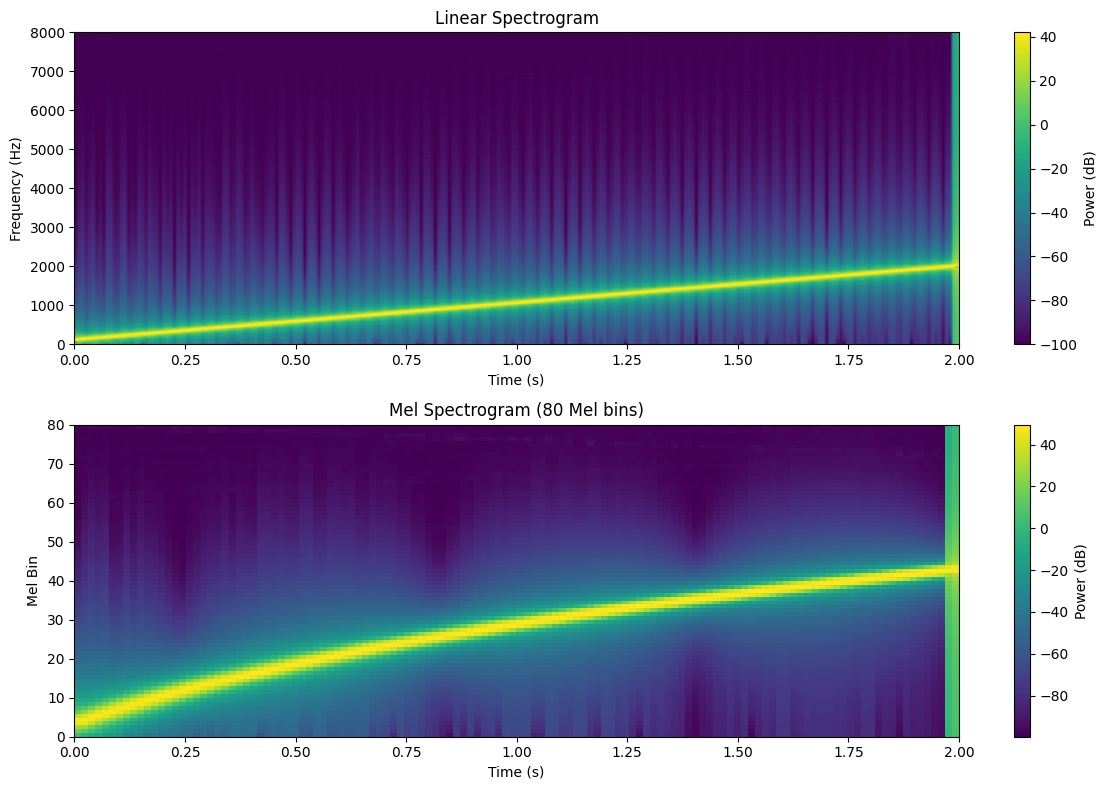


Note: Mel spectrogram has higher resolution at lower frequencies,
matching human perception.


In [17]:
# Create Mel spectrogram
n_mels = 80  # Number of Mel frequency bins
n_fft = 1024
hop_length = 256

# Using torchaudio
mel_transform = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    f_min=0,
    f_max=sample_rate // 2
)

mel_spec = mel_transform(chirp_tensor)
mel_spec_db = 10 * torch.log10(mel_spec + 1e-10)

print(f"Mel spectrogram shape: {mel_spec.shape}")
print(f"  - Batch size: {mel_spec.shape[0]}")
print(f"  - Mel bins: {mel_spec.shape[1]}")
print(f"  - Time frames: {mel_spec.shape[2]}")

# Compare linear and Mel spectrogram
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Linear spectrogram
linear_spec = stft_transform(chirp_tensor)
linear_spec_db = 10 * torch.log10(linear_spec + 1e-10)

img1 = axes[0].imshow(
    linear_spec_db.squeeze().numpy(),
    aspect='auto',
    origin='lower',
    extent=[0, duration, 0, sample_rate/2],
    cmap='viridis'
)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('Linear Spectrogram')
plt.colorbar(img1, ax=axes[0], label='Power (dB)')

# Mel spectrogram
img2 = axes[1].imshow(
    mel_spec_db.squeeze().numpy(),
    aspect='auto',
    origin='lower',
    extent=[0, duration, 0, n_mels],
    cmap='viridis'
)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Mel Bin')
axes[1].set_title('Mel Spectrogram (80 Mel bins)')
plt.colorbar(img2, ax=axes[1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\nNote: Mel spectrogram has higher resolution at lower frequencies,")
print("matching human perception.")

## 3.6 Mel-Frequency Cepstral Coefficients (MFCCs)

MFCCs were the dominant feature for speech recognition before deep learning.

MFCC shape: torch.Size([1, 13, 126])
  - 13 coefficients per frame
  - 126 frames

Full MFCC features (with deltas): torch.Size([1, 39, 126])
  - 13 MFCC + 13 delta + 13 delta-delta = 39 features per frame


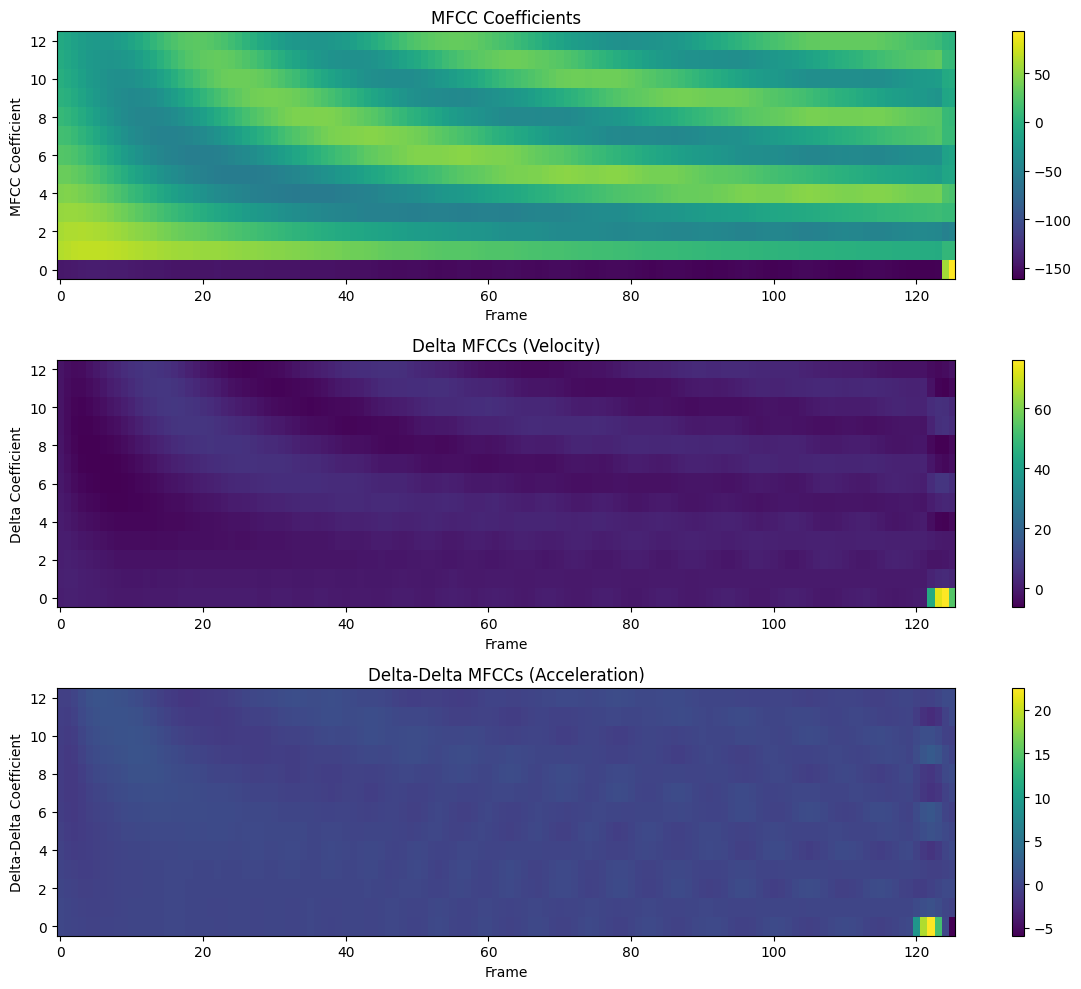

In [18]:
# Compute MFCCs
n_mfcc = 13  # Number of MFCC coefficients

mfcc_transform = T.MFCC(
    sample_rate=sample_rate,
    n_mfcc=n_mfcc,
    melkwargs={
        'n_fft': 1024,
        'hop_length': 256,
        'n_mels': 40
    }
)

mfcc = mfcc_transform(chirp_tensor)

print(f"MFCC shape: {mfcc.shape}")
print(f"  - {mfcc.shape[1]} coefficients per frame")
print(f"  - {mfcc.shape[2]} frames")

# Compute delta and delta-delta (velocity and acceleration)
delta = torchaudio.functional.compute_deltas(mfcc)
delta_delta = torchaudio.functional.compute_deltas(delta)

# Combine into 39-dimensional feature vector
mfcc_full = torch.cat([mfcc, delta, delta_delta], dim=1)
print(f"\nFull MFCC features (with deltas): {mfcc_full.shape}")
print(f"  - 13 MFCC + 13 delta + 13 delta-delta = 39 features per frame")

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# MFCCs
img1 = axes[0].imshow(
    mfcc.squeeze().numpy(),
    aspect='auto',
    origin='lower',
    cmap='viridis'
)
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('MFCC Coefficient')
axes[0].set_title('MFCC Coefficients')
plt.colorbar(img1, ax=axes[0])

# Delta MFCCs
img2 = axes[1].imshow(
    delta.squeeze().numpy(),
    aspect='auto',
    origin='lower',
    cmap='viridis'
)
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Delta Coefficient')
axes[1].set_title('Delta MFCCs (Velocity)')
plt.colorbar(img2, ax=axes[1])

# Delta-Delta MFCCs
img3 = axes[2].imshow(
    delta_delta.squeeze().numpy(),
    aspect='auto',
    origin='lower',
    cmap='viridis'
)
axes[2].set_xlabel('Frame')
axes[2].set_ylabel('Delta-Delta Coefficient')
axes[2].set_title('Delta-Delta MFCCs (Acceleration)')
plt.colorbar(img3, ax=axes[2])

plt.tight_layout()
plt.show()

---
# 4. Deep Learning for Audio

## 4.1 CNN for Audio Classification

Spectrograms can be treated as images, making CNNs a natural choice.

In [19]:
import torch.nn as nn

class AudioCNN(nn.Module):
    """Simple CNN for audio classification from Mel spectrograms."""
    
    def __init__(self, n_mels=80, num_classes=10):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            # Conv block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Conv block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Conv block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # Global average pooling
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch, 1, n_mels, time)
        features = self.conv_layers(x)
        output = self.classifier(features)
        return output

# Create model and show architecture
model = AudioCNN(n_mels=80, num_classes=10)
print(model)

# Test with sample input
sample_input = torch.randn(4, 1, 80, 200)  # Batch of 4, 80 mel bins, 200 time frames
output = model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

AudioCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=10, bias=True)
  )
)

Input shape: torch.Size([4, 1, 80, 200])
Output shape: torch.

## 4.2 RNNs for Sequential Audio

Audio is inherently sequential. RNNs (especially LSTMs) can model temporal dependencies.

In [20]:
class AudioLSTM(nn.Module):
    """LSTM-based model for audio sequence modeling."""
    
    def __init__(self, input_size=80, hidden_size=256, num_layers=2, 
                 num_classes=10, bidirectional=True):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3
        )
        
        lstm_output_size = hidden_size * 2 if bidirectional else hidden_size
        
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch, time, features)
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Use the last hidden state
        # For bidirectional: concatenate last forward and first backward
        if self.lstm.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]
        
        output = self.classifier(hidden)
        return output

# Create and test LSTM model
lstm_model = AudioLSTM(input_size=80, hidden_size=256, num_classes=10)
print(lstm_model)

# Test with sample input (batch, time, features)
sample_input = torch.randn(4, 200, 80)  # Batch of 4, 200 time steps, 80 features
output = lstm_model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"Total parameters: {total_params:,}")

AudioLSTM(
  (lstm): LSTM(80, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Input shape: torch.Size([4, 200, 80])
Output shape: torch.Size([4, 10])
Total parameters: 2,336,138


## 4.3 CRNN: CNN + RNN Hybrid

Combine CNN's ability to extract local patterns with RNN's sequential modeling.

In [21]:
class AudioCRNN(nn.Module):
    """CNN + RNN hybrid for audio classification."""
    
    def __init__(self, n_mels=80, num_classes=10):
        super().__init__()
        
        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),  # Pool only in frequency
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
        )
        
        # After CNN: (batch, 128, n_mels//8, time)
        # Reshape to: (batch, time, 128 * n_mels//8)
        cnn_output_freq = n_mels // 8
        
        self.rnn = nn.LSTM(
            input_size=128 * cnn_output_freq,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        
        self.classifier = nn.Linear(256, num_classes)  # 128 * 2 for bidirectional
    
    def forward(self, x):
        # x shape: (batch, 1, n_mels, time)
        batch_size = x.size(0)
        
        # CNN features
        cnn_out = self.cnn(x)  # (batch, 128, freq', time)
        
        # Reshape for RNN: (batch, time, features)
        cnn_out = cnn_out.permute(0, 3, 1, 2)  # (batch, time, 128, freq')
        cnn_out = cnn_out.reshape(batch_size, cnn_out.size(1), -1)  # (batch, time, 128*freq')
        
        # RNN
        rnn_out, (hidden, _) = self.rnn(cnn_out)
        
        # Global average pooling over time
        pooled = rnn_out.mean(dim=1)
        
        output = self.classifier(pooled)
        return output

# Create and test CRNN model
crnn_model = AudioCRNN(n_mels=80, num_classes=10)
print(crnn_model)

# Test with sample input
sample_input = torch.randn(4, 1, 80, 200)
output = crnn_model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

total_params = sum(p.numel() for p in crnn_model.parameters())
print(f"Total parameters: {total_params:,}")

AudioCRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (rnn): LSTM(1280, 128, num_layers=2, batch_first=True, bidirectional=True)
  (classifier): Linear(in_features=256, out_features=10, bias=

## 4.4 Dilated Causal Convolutions (TCN / WaveNet style)

Dilated convolutions enable large receptive fields without increasing parameters.

In [22]:
class CausalConv1d(nn.Module):
    """Causal convolution - only looks at past and present."""
    
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=self.padding, dilation=dilation
        )
    
    def forward(self, x):
        out = self.conv(x)
        # Remove future samples (causal)
        return out[:, :, :-self.padding] if self.padding > 0 else out

class TCNBlock(nn.Module):
    """Temporal Convolutional Network block with dilated causal convolutions."""
    
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
        # Residual connection
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
    
    def forward(self, x):
        out = self.dropout(self.relu(self.conv1(x)))
        out = self.dropout(self.relu(self.conv2(out)))
        return out + self.residual(x)

class TCN(nn.Module):
    """Temporal Convolutional Network for audio."""
    
    def __init__(self, input_size, num_channels, kernel_size=3, num_classes=10):
        super().__init__()
        
        layers = []
        num_layers = len(num_channels)
        
        for i in range(num_layers):
            in_ch = input_size if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            dilation = 2 ** i  # Exponentially increasing dilation
            layers.append(TCNBlock(in_ch, out_ch, kernel_size, dilation))
        
        self.tcn = nn.Sequential(*layers)
        self.classifier = nn.Linear(num_channels[-1], num_classes)
    
    def forward(self, x):
        # x shape: (batch, features, time)
        out = self.tcn(x)
        # Global average pooling
        out = out.mean(dim=-1)
        return self.classifier(out)

# Create TCN model
tcn_model = TCN(input_size=80, num_channels=[64, 64, 128, 128], num_classes=10)
print(tcn_model)

# Calculate receptive field
kernel_size = 3
num_layers = 4
receptive_field = 1 + sum([(kernel_size - 1) * 2**i * 2 for i in range(num_layers)])
print(f"\nReceptive field: {receptive_field} samples")
print(f"At 16kHz with hop=256: {receptive_field * 256 / 16000 * 1000:.0f} ms")

# Test
sample_input = torch.randn(4, 80, 200)  # (batch, features, time)
output = tcn_model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

TCN(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(80, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (conv2): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Conv1d(80, 64, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      )
      (conv2): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      )
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
    (2): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
      )
      (conv2): CausalConv1d(
        (conv): Conv1d(128, 128, ker

## 4.5 Self-Attention for Audio (Transformer)

Self-attention allows every position to attend to every other position.

In [23]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

class AudioTransformer(nn.Module):
    """Transformer-based model for audio classification."""
    
    def __init__(self, input_dim=80, d_model=256, nhead=8, 
                 num_layers=4, num_classes=10):
        super().__init__()
        
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_model // 2, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch, time, features)
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        
        # Global average pooling
        x = x.mean(dim=1)
        
        return self.classifier(x)

# Create Transformer model
transformer_model = AudioTransformer(input_dim=80, d_model=256, num_classes=10)
print(transformer_model)

# Test
sample_input = torch.randn(4, 200, 80)  # (batch, time, features)
output = transformer_model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"Total parameters: {total_params:,}")

AudioTransformer(
  (input_projection): Linear(in_features=80, out_features=256, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3

---
# 5. Data Augmentation for Audio

Data augmentation is crucial for audio models to prevent overfitting.

In [24]:
# Generate sample audio for augmentation demonstrations
sample_rate = 16000
duration = 2.0
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Create a more interesting signal with harmonics
fundamental = 220  # A3
audio = (
    np.sin(2 * np.pi * fundamental * t) +
    0.5 * np.sin(2 * np.pi * 2 * fundamental * t) +
    0.25 * np.sin(2 * np.pi * 3 * fundamental * t)
)
audio = audio / np.max(np.abs(audio))  # Normalize
audio_tensor = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)

print("Original audio:")
display(Audio(audio, rate=sample_rate))

Original audio:


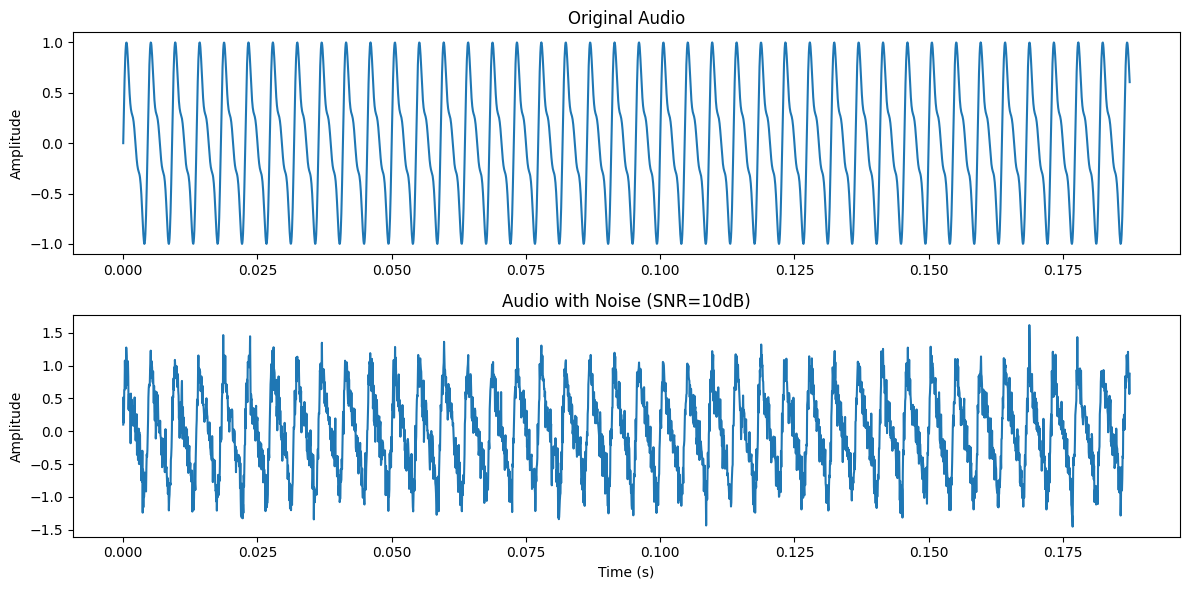

Audio with noise:


In [25]:
# 1. Noise Injection
def add_noise(waveform, snr_db=20):
    """Add Gaussian noise at specified SNR."""
    signal_power = waveform.pow(2).mean()
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = torch.randn_like(waveform) * noise_power.sqrt()
    return waveform + noise

noisy_audio = add_noise(audio_tensor, snr_db=10)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t[:3000], audio[:3000])
axes[0].set_title('Original Audio')
axes[0].set_ylabel('Amplitude')
axes[1].plot(t[:3000], noisy_audio.squeeze().numpy()[:3000])
axes[1].set_title('Audio with Noise (SNR=10dB)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

print("Audio with noise:")
display(Audio(noisy_audio.squeeze().numpy(), rate=sample_rate))

In [26]:
# 2. Time Stretching and Pitch Shifting using librosa
# Time stretch (without changing pitch)
stretched_fast = librosa.effects.time_stretch(audio, rate=1.2)  # 20% faster
stretched_slow = librosa.effects.time_stretch(audio, rate=0.8)  # 20% slower

# Pitch shift (without changing duration)
pitch_up = librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=2)  # 2 semitones up
pitch_down = librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=-2)  # 2 semitones down

print("Time Stretched (faster):")
display(Audio(stretched_fast, rate=sample_rate))

print("Time Stretched (slower):")
display(Audio(stretched_slow, rate=sample_rate))

print("Pitch Shifted (up):")
display(Audio(pitch_up, rate=sample_rate))

print("Pitch Shifted (down):")
display(Audio(pitch_down, rate=sample_rate))

Time Stretched (faster):


Time Stretched (slower):


Pitch Shifted (up):


Pitch Shifted (down):


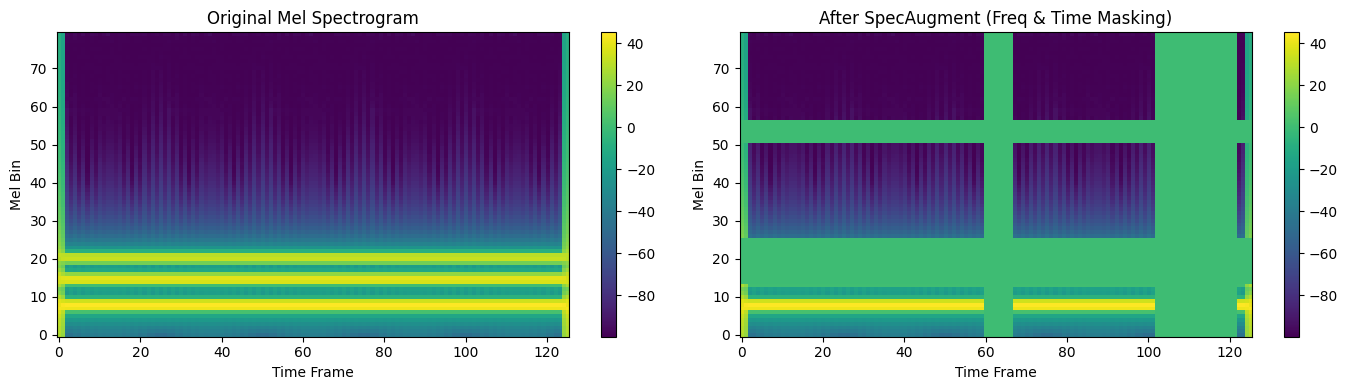

SpecAugment randomly masks frequency bands and time segments.
This forces the model to learn robust features.


In [27]:
# 3. SpecAugment - Augmentation on spectrograms
def spec_augment(spec, freq_mask_param=15, time_mask_param=35, 
                 num_freq_masks=2, num_time_masks=2):
    """Apply SpecAugment to a spectrogram."""
    spec = spec.clone()
    
    n_freq, n_time = spec.shape[-2], spec.shape[-1]
    
    # Frequency masking
    for _ in range(num_freq_masks):
        f = np.random.randint(0, freq_mask_param)
        f0 = np.random.randint(0, max(1, n_freq - f))
        spec[..., f0:f0+f, :] = 0
    
    # Time masking
    for _ in range(num_time_masks):
        t = np.random.randint(0, time_mask_param)
        t0 = np.random.randint(0, max(1, n_time - t))
        spec[..., :, t0:t0+t] = 0
    
    return spec

# Create mel spectrogram
mel_spec = mel_transform(audio_tensor)
mel_spec_db = 10 * torch.log10(mel_spec + 1e-10)

# Apply SpecAugment
augmented_spec = spec_augment(mel_spec_db.clone())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

img1 = axes[0].imshow(mel_spec_db.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original Mel Spectrogram')
axes[0].set_xlabel('Time Frame')
axes[0].set_ylabel('Mel Bin')
plt.colorbar(img1, ax=axes[0])

img2 = axes[1].imshow(augmented_spec.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('After SpecAugment (Freq & Time Masking)')
axes[1].set_xlabel('Time Frame')
axes[1].set_ylabel('Mel Bin')
plt.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.show()

print("SpecAugment randomly masks frequency bands and time segments.")
print("This forces the model to learn robust features.")

---
# 6. Complete Audio Classification Pipeline

Let's put it all together with a complete training example.

In [28]:
from torch.utils.data import Dataset, DataLoader

class SyntheticAudioDataset(Dataset):
    """Synthetic dataset for demonstration - generates audio on the fly."""
    
    def __init__(self, num_samples=1000, sample_rate=16000, duration=1.0, 
                 n_mels=80, num_classes=5):
        self.num_samples = num_samples
        self.sample_rate = sample_rate
        self.duration = duration
        self.num_classes = num_classes
        
        # Pre-compute mel transform
        self.mel_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=1024,
            hop_length=256,
            n_mels=n_mels
        )
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Generate random class
        label = idx % self.num_classes
        
        # Generate audio based on class (different frequency ranges)
        t = np.linspace(0, self.duration, int(self.sample_rate * self.duration), endpoint=False)
        base_freq = 200 + label * 150  # Different base frequency per class
        
        # Add harmonics and some noise
        audio = (
            np.sin(2 * np.pi * base_freq * t) +
            0.5 * np.sin(2 * np.pi * 2 * base_freq * t) +
            0.3 * np.random.randn(len(t)) * 0.1
        )
        audio = audio / np.max(np.abs(audio))
        
        # Convert to tensor and compute mel spectrogram
        waveform = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)
        mel_spec = self.mel_transform(waveform)
        mel_spec_db = 10 * torch.log10(mel_spec + 1e-10)
        
        return mel_spec_db, label

# Create datasets
train_dataset = SyntheticAudioDataset(num_samples=500, num_classes=5)
val_dataset = SyntheticAudioDataset(num_samples=100, num_classes=5)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Show sample
sample_mel, sample_label = train_dataset[0]
print(f"Sample mel spectrogram shape: {sample_mel.shape}")
print(f"Sample label: {sample_label}")

Sample mel spectrogram shape: torch.Size([1, 80, 63])
Sample label: 0


In [29]:
# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_mel, batch_labels in loader:
        batch_mel = batch_mel.to(device)
        batch_labels = batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_mel)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += batch_labels.size(0)
        correct += predicted.eq(batch_labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_mel, batch_labels in loader:
            batch_mel = batch_mel.to(device)
            batch_labels = batch_labels.to(device)
            
            outputs = model(batch_mel)
            loss = criterion(outputs, batch_labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += batch_labels.size(0)
            correct += predicted.eq(batch_labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

In [30]:
# Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = AudioCNN(n_mels=80, num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train for a few epochs
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Using device: cpu
Epoch 1/10: Train Loss: 1.0607, Train Acc: 78.20%, Val Loss: 0.8783, Val Acc: 100.00%
Epoch 2/10: Train Loss: 0.4457, Train Acc: 100.00%, Val Loss: 0.2764, Val Acc: 100.00%
Epoch 3/10: Train Loss: 0.2073, Train Acc: 100.00%, Val Loss: 0.1319, Val Acc: 100.00%
Epoch 4/10: Train Loss: 0.1112, Train Acc: 100.00%, Val Loss: 0.0787, Val Acc: 100.00%
Epoch 5/10: Train Loss: 0.0653, Train Acc: 100.00%, Val Loss: 0.0418, Val Acc: 100.00%
Epoch 6/10: Train Loss: 0.0428, Train Acc: 100.00%, Val Loss: 0.0321, Val Acc: 100.00%
Epoch 7/10: Train Loss: 0.0313, Train Acc: 100.00%, Val Loss: 0.0241, Val Acc: 100.00%
Epoch 8/10: Train Loss: 0.0258, Train Acc: 100.00%, Val Loss: 0.0203, Val Acc: 100.00%
Epoch 9/10: Train Loss: 0.0193, Train Acc: 100.00%, Val Loss: 0.0156, Val Acc: 100.00%
Epoch 10/10: Train Loss: 0.0185, Train Acc: 100.00%, Val Loss: 0.0137, Val Acc: 100.00%


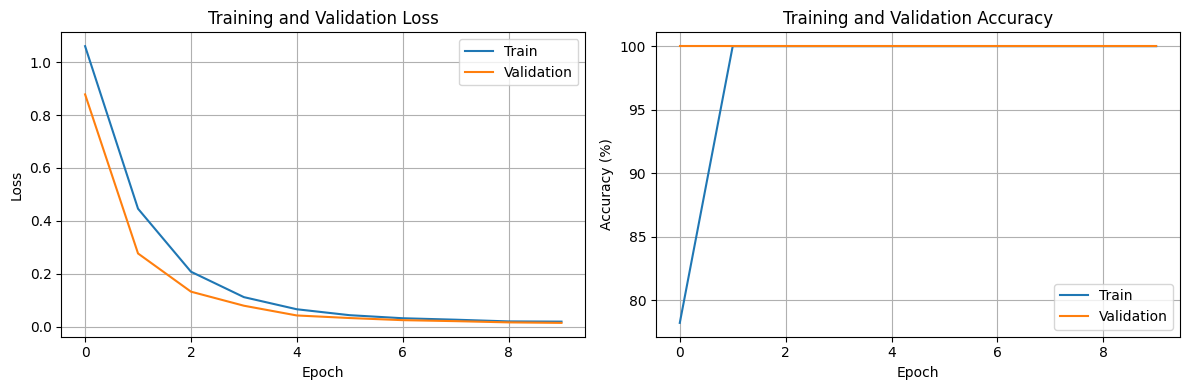

In [31]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
# 7. Evaluation Metrics

## 7.1 Classification Metrics

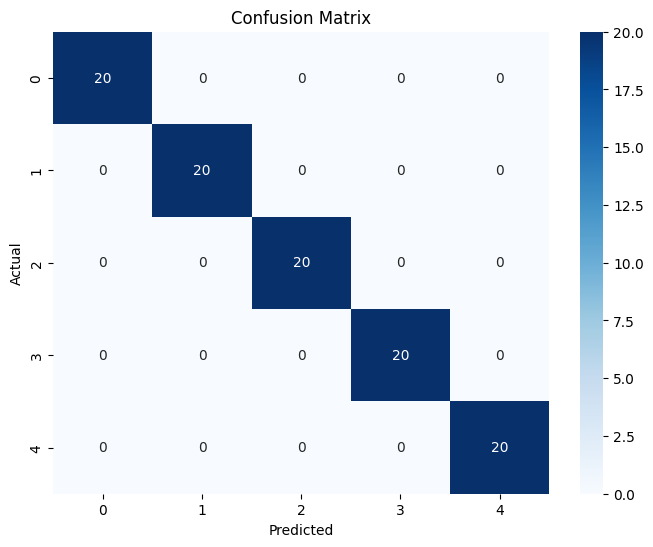

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions on validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_mel, batch_labels in val_loader:
        batch_mel = batch_mel.to(device)
        outputs = model(batch_mel)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds))

## 7.2 Word Error Rate (WER) for ASR

WER is the standard metric for speech recognition.

In [33]:
def word_error_rate(reference, hypothesis):
    """Calculate Word Error Rate using Levenshtein distance."""
    ref_words = reference.lower().split()
    hyp_words = hypothesis.lower().split()
    
    # Dynamic programming for edit distance
    r = len(ref_words)
    h = len(hyp_words)
    
    # Initialize DP table
    d = [[0] * (h + 1) for _ in range(r + 1)]
    
    for i in range(r + 1):
        d[i][0] = i
    for j in range(h + 1):
        d[0][j] = j
    
    # Fill the table
    for i in range(1, r + 1):
        for j in range(1, h + 1):
            if ref_words[i-1] == hyp_words[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                substitution = d[i-1][j-1] + 1
                insertion = d[i][j-1] + 1
                deletion = d[i-1][j] + 1
                d[i][j] = min(substitution, insertion, deletion)
    
    # WER = (S + D + I) / N
    wer = d[r][h] / r if r > 0 else 0
    return wer, d[r][h], r

# Example
reference = "the cat sat on the mat"
hypothesis = "a cat sat the mat"

wer, errors, total_words = word_error_rate(reference, hypothesis)
print(f"Reference:  '{reference}'")
print(f"Hypothesis: '{hypothesis}'")
print(f"\nWord Error Rate: {wer:.2%}")
print(f"Errors (S+D+I): {errors}")
print(f"Reference words: {total_words}")

Reference:  'the cat sat on the mat'
Hypothesis: 'a cat sat the mat'

Word Error Rate: 33.33%
Errors (S+D+I): 2
Reference words: 6


---
# 8. Summary and Key Takeaways

## Key Concepts Covered:

### 1. Audio Fundamentals
- Sound is a pressure wave; digital audio is discrete samples
- Nyquist theorem: sample rate must be ≥ 2× max frequency
- Common sample rates: 16kHz (speech), 44.1kHz (music)

### 2. Time-Frequency Analysis
- DFT/FFT: Convert time domain → frequency domain
- STFT: Frequency content over time (spectrograms)
- Mel scale: Perceptually-motivated frequency scale
- MFCCs: Classical compact audio features

### 3. Deep Learning Architectures
- **CNN**: Treats spectrograms as images; good for local patterns
- **RNN/LSTM**: Models sequential dependencies
- **CRNN**: Best of both - CNN features + RNN sequence modeling
- **TCN**: Dilated convolutions for large receptive fields
- **Transformer**: Self-attention for global context

### 4. Data Augmentation
- Noise injection, time stretching, pitch shifting
- SpecAugment: Mask frequency/time bands on spectrograms

### 5. Evaluation
- Classification: Accuracy, F1, Confusion Matrix
- ASR: Word Error Rate (WER)
- Audio quality: SNR, PESQ, STOI

In [ ]:
# Quick Reference: Common Hyperparameters
print("="*60)
print("QUICK REFERENCE: Common Audio Processing Parameters")
print("="*60)

params = {
    "Sample Rate (speech)": "16,000 Hz",
    "Sample Rate (music)": "44,100 Hz",
    "Frame Length": "25 ms (400 samples @ 16kHz)",
    "Hop Size": "10 ms (160 samples @ 16kHz)",
    "FFT Size": "512 or 1024 (power of 2)",
    "Mel Bins": "80 (neural TTS), 40 (MFCCs)",
    "MFCC Coefficients": "13 (+ 13 delta + 13 delta-delta = 39)",
}

for param, value in params.items():
    print(f"{param:25s}: {value}")

print("\n" + "="*60)
print("KEY LIBRARIES")
print("="*60)
libraries = [
    ("torchaudio", "PyTorch audio I/O and transforms"),
    ("librosa", "Audio analysis (Python)"),
    ("soundfile", "Audio file reading/writing"),
    ("speechbrain", "End-to-end speech toolkit"),
    ("whisper", "OpenAI's speech recognition"),
]
for lib, desc in libraries:
    print(f"{lib:15s}: {desc}")